# Proyecto Final PLN: Análisis de Críticas de Cine en Español

## Notas para ejecutar este notebook

- **Activar GPU antes de correr**: `Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU` (necesario para la sección de BETO).
- **Tiempo total de ejecución**: ~25-35 minutos (la sección de BETO es la que más tarda).
- **No requiere API keys ni configuración adicional** — el dataset se carga públicamente desde HuggingFace.
- Si solo desea revisar resultados sin ejecutar, los outputs (gráficas, métricas) ya quedan guardados en las celdas al momento de la entrega.

**Sección 1 — Instalación y datos:**

In [1]:
!pip install datasets spacy gensim scikit-learn matplotlib seaborn transformers accelerate gradio -q
!python -m spacy download es_core_news_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 106.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
from datasets import load_dataset
ds = load_dataset("us-lsi/muchocine", revision="refs/convert/parquet")
df = ds["train"].to_pandas()
print(df.shape)

default/train/0000.parquet:   0%|          | 0.00/7.68M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

(3872, 3)


In [3]:
import torch
print("GPU disponible:", torch.cuda.is_available())

GPU disponible: True


In [4]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("us-lsi/muchocine", revision="refs/convert/parquet")
df = ds["train"].to_pandas()
print("Dataset cargado:", df.shape)
print(df.head(3))

Dataset cargado: (3872, 3)
                                         review_body  \
0  "May, ¿Quieres ser mi amigo?" es una de esas p...   
1  Es todo un alivio que ante tanta película que ...   
2  Una fiesta llena de excesos, rubias despampana...   

                                      review_summary  star_rating  
0                       May, ¿quieres ser mi amigo?             3  
1            Cómo ponerse en la piel de un kamikaze             3  
2  Silicona, esteroides, pactos demoníacos y otra...            0  


**Sección 2: Preprocesamiento**

In [5]:
import re
import spacy

class Preprocesador:
    NEGACIONES = {"no", "nunca", "jamás", "jamas", "tampoco", "ni", "sin", "nadie",
                  "nada", "ningún", "ningun", "ninguna", "ninguno"}
    PALABRAS_SENTIMIENTO = {"bien", "mal", "buen", "buena", "buenas", "buenos",
                             "mejor", "mejores", "peor", "peores", "mucho", "muchos",
                             "muy", "poco", "pocos", "poca", "pocas", "más", "mas", "menos"}

    def __init__(self, modelo_spacy="es_core_news_sm"):
        self.nlp = spacy.load(modelo_spacy, disable=["parser", "ner"])
        self.stopwords = set(self.nlp.Defaults.stop_words)
        self.stopwords -= self.NEGACIONES
        self.stopwords -= self.PALABRAS_SENTIMIENTO

    def limpiar(self, texto):
        if not isinstance(texto, str):
            return ""
        texto = texto.lower()
        texto = re.sub(r"<[^>]+>", " ", texto)
        texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
        texto = re.sub(r"@\w+", " ", texto)
        texto = re.sub(r"#(\w+)", r"\1", texto)
        texto = re.sub(r"(.)\1{2,}", r"\1", texto)
        texto = re.sub(r"[^a-záéíóúñü0-9\s]", " ", texto)
        texto = re.sub(r"\s+", " ", texto).strip()
        return texto

    def tokenizar_y_lematizar(self, texto_limpio):
        doc = self.nlp(texto_limpio)
        tokens = []
        protegidas = self.NEGACIONES | self.PALABRAS_SENTIMIENTO
        for token in doc:
            if token.is_space or token.is_punct:
                continue
            if len(token.text) < 2 and token.text not in protegidas:
                continue
            if token.text in self.stopwords:
                continue
            tokens.append(token.lemma_)
        return tokens

    def pipeline_completo(self, texto):
        limpio = self.limpiar(texto)
        tokens = self.tokenizar_y_lematizar(limpio)
        return " ".join(tokens)

    def limpiar_para_transformer(self, texto):
        if not isinstance(texto, str):
            return ""
        texto = re.sub(r"<[^>]+>", " ", texto)
        texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
        texto = re.sub(r"@\w+", " ", texto)
        texto = re.sub(r"\s+", " ", texto).strip()
        return texto


def rating_a_sentimiento(rating):
    if rating <= 1:
        return "negativo"
    elif rating == 2:
        return "neutral"
    else:
        return "positivo"

print("Clase Preprocesador definida")

Clase Preprocesador definida


In [6]:
prep = Preprocesador()

df["sentimiento"] = df["star_rating"].apply(rating_a_sentimiento)
df["texto_procesado"] = df["review_body"].apply(prep.pipeline_completo)
df["texto_transformer"] = df["review_body"].apply(prep.limpiar_para_transformer)
df["texto_procesado"] = df["texto_procesado"].fillna("vacio")

print("Preprocesamiento terminado")
print(df["sentimiento"].value_counts())

Preprocesamiento terminado
sentimiento
positivo    1350
negativo    1273
neutral     1249
Name: count, dtype: int64


**Sección 3: Modelado de temas (LDA)**

In [7]:
from gensim.models.phrases import Phrases, Phraser
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

palabras_genericas_lda = {"poco", "ni", "mejor", "peor", "momento", "año", "cosa", "nada",
                           "resultar", "dejar", "mucho", "muy", "menos", "mas", "más",
                           "bien", "mal", "buen", "pasar", "forma", "tiempo", "vez"}

def quitar_genericas(texto):
    return " ".join(w for w in texto.split() if w not in palabras_genericas_lda)

df["texto_lda"] = df["texto_procesado"].apply(quitar_genericas)
tokens_por_doc = [t.split() for t in df["texto_lda"]]

bigramas = Phrases(tokens_por_doc, min_count=15, threshold=50)
bigram_model = Phraser(bigramas)
tokens_con_bigramas = [bigram_model[doc] for doc in tokens_por_doc]

diccionario = corpora.Dictionary(tokens_con_bigramas)
diccionario.filter_extremes(no_below=10, no_above=0.35, keep_n=3000)
corpus_bow = [diccionario.doc2bow(t) for t in tokens_con_bigramas]

print("Entrenando LDA...")
modelo_lda = LdaModel(
    corpus=corpus_bow, id2word=diccionario, num_topics=6,
    passes=30, iterations=400, random_state=42, alpha="auto", eta="auto",
)

for idx, tema in modelo_lda.print_topics(num_topics=6, num_words=10):
    palabras = [p.split("*")[1].strip().replace('"', "") for p in tema.split(" + ")]
    print(f"Tema {idx}: {', '.join(palabras)}")

coherence_model = CoherenceModel(model=modelo_lda, texts=tokens_con_bigramas, dictionary=diccionario, coherence="c_v")
print("\nCoherencia:", coherence_model.get_coherence())

Entrenando LDA...
Tema 0: film, interpretación, papel, trabajo, cinta, encontrar, joven, comedia, actriz, mujer
Tema 1: film, trama, mundo, policía, género, violencia, cinta, caso, hombre, clásico
Tema 2: mundo, vivir, querer, gustar, mujer, poner, quedar, padre, haber, guerra
Tema 3: cinta, acción, pantalla, haber, quedar, saga, film, hora, serie, papel
Tema 4: peli, malo, salir, comedia, gustar, tipo, terror, decir, quedar, humor
Tema 5: mundo, humano, imagen, obra, relato, visual, plano, film, mostrar, realidad

Coherencia: 0.3281686220107134


In [8]:
def tema_dominante(texto_tokens, modelo, diccionario):
    bow = diccionario.doc2bow(texto_tokens)
    distribucion = modelo.get_document_topics(bow)
    if len(distribucion) == 0:
        return -1
    return max(distribucion, key=lambda x: x[1])[0]

df["tema_id"] = [tema_dominante(toks, modelo_lda, diccionario) for toks in tokens_con_bigramas]

nombres_temas = {
    0: "Actuación / interpretación actoral",
    1: "Cine policial / género negro",
    2: "Drama familiar / social español",
    3: "Acción / sagas de Hollywood",
    4: "Terror / comedia de bajo presupuesto",
    5: "Cine de autor / lenguaje visual",
}
df["tema_nombre"] = df["tema_id"].map(nombres_temas)

print(df["tema_nombre"].value_counts())

tema_nombre
Actuación / interpretación actoral      1159
Acción / sagas de Hollywood              982
Terror / comedia de bajo presupuesto     536
Drama familiar / social español          515
Cine de autor / lenguaje visual          404
Cine policial / género negro             276
Name: count, dtype: int64


**Sección 4: Naive Bayes (clásico)**

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


class ClasificadorClasico:
    def __init__(self, max_features=5000, ngram_range=(1, 2), test_size=0.2, random_state=42):
        self.vectorizador = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.modelo = MultinomialNB()
        self.test_size = test_size
        self.random_state = random_state
        self.clases = None

    def entrenar(self, textos, etiquetas):
        X_train, X_test, y_train, y_test = train_test_split(
            textos, etiquetas, test_size=self.test_size,
            random_state=self.random_state, stratify=etiquetas,
        )
        X_train_tfidf = self.vectorizador.fit_transform(X_train)
        X_test_tfidf = self.vectorizador.transform(X_test)
        self.modelo.fit(X_train_tfidf, y_train)
        self.X_test_tfidf = X_test_tfidf
        self.y_test = y_test
        self.y_pred = self.modelo.predict(X_test_tfidf)
        self.clases = sorted(etiquetas.unique())
        return self.modelo

    def evaluar(self):
        acc = accuracy_score(self.y_test, self.y_pred)
        print(f"Exactitud (accuracy): {acc:.4f}\n")
        print(classification_report(self.y_test, self.y_pred))
        return acc

    def matriz_confusion(self):
        cm = confusion_matrix(self.y_test, self.y_pred, labels=self.clases)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.clases, yticklabels=self.clases)
        plt.xlabel("Predicción")
        plt.ylabel("Real")
        plt.title("Matriz de confusión - Naive Bayes")
        plt.tight_layout()
        plt.show()

    def predecir(self, texto_procesado_individual):
        vector = self.vectorizador.transform([texto_procesado_individual])
        return self.modelo.predict(vector)[0]


clf_nb = ClasificadorClasico()
clf_nb.entrenar(df["texto_procesado"], df["sentimiento"])
clf_nb.evaluar()

Exactitud (accuracy): 0.5935

              precision    recall  f1-score   support

    negativo       0.63      0.67      0.65       255
     neutral       0.52      0.36      0.43       250
    positivo       0.61      0.73      0.66       270

    accuracy                           0.59       775
   macro avg       0.58      0.59      0.58       775
weighted avg       0.58      0.59      0.58       775



0.5935483870967742

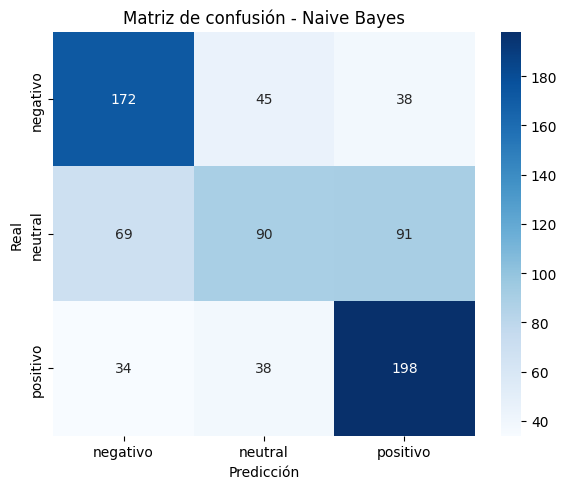

In [10]:
clf_nb.matriz_confusion()

**Sección 5: BETO (neuronal)**

Se realizaron tres corridas preliminares con distinto número de épocas para
observar la convergencia del modelo: 1 época (46.6% accuracy), 2 épocas
(50.8%), y 3 épocas (54.5%). Se documenta aquí únicamente la corrida final
de 3 épocas, dado el tiempo de cómputo disponible.

In [11]:
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import precision_recall_fscore_support


MODELO_BASE = "dccuchile/bert-base-spanish-wwm-uncased"
ETIQUETAS = ["negativo", "neutral", "positivo"]
ETIQUETA_A_ID = {e: i for i, e in enumerate(ETIQUETAS)}
ID_A_ETIQUETA = {i: e for i, e in enumerate(ETIQUETAS)}


class DatasetSentimiento(Dataset):
    def __init__(self, textos, etiquetas, tokenizer, max_length=128):
        textos_limpios = [str(t) if pd.notna(t) and str(t).strip() != "" else "vacio" for t in textos]
        self.encodings = tokenizer(textos_limpios, truncation=True, padding=True, max_length=max_length)
        self.labels = [ETIQUETA_A_ID[e] for e in etiquetas]

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


def calcular_metricas(eval_pred):
    logits, labels = eval_pred
    predicciones = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predicciones)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predicciones, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)
modelo_beto = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, num_labels=3)

X_train, X_test, y_train, y_test = train_test_split(
    df["texto_transformer"], df["sentimiento"], test_size=0.2, random_state=42, stratify=df["sentimiento"]
)

dataset_train = DatasetSentimiento(X_train, y_train, tokenizer)
dataset_test = DatasetSentimiento(X_test, y_test, tokenizer)
y_test_ids = [ETIQUETA_A_ID[e] for e in y_test]

args_entrenamiento = TrainingArguments(
    output_dir="./resultados_beto",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=modelo_beto, args=args_entrenamiento,
    train_dataset=dataset_train, eval_dataset=dataset_test,
    compute_metrics=calcular_metricas,
)

print("Iniciando entrenamiento de BETO...")
trainer.train()
print("Entrenamiento terminado")

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.058231,1.009856,0.480000,0.484386,0.480000,0.437699
2,0.860146,0.992444,0.517419,0.519072,0.517419,0.517906
3,0.630390,1.066826,0.500645,0.503364,0.500645,0.498737


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Entrenamiento terminado


In [12]:
predicciones_raw = trainer.predict(dataset_test)
y_pred_beto = np.argmax(predicciones_raw.predictions, axis=-1)

acc_beto = accuracy_score(y_test_ids, y_pred_beto)
print(f"Exactitud BETO: {acc_beto:.4f}\n")
print(classification_report(y_test_ids, y_pred_beto, target_names=ETIQUETAS))

Exactitud BETO: 0.5174

              precision    recall  f1-score   support

    negativo       0.56      0.58      0.57       255
     neutral       0.42      0.43      0.42       250
    positivo       0.58      0.54      0.56       270

    accuracy                           0.52       775
   macro avg       0.52      0.52      0.52       775
weighted avg       0.52      0.52      0.52       775



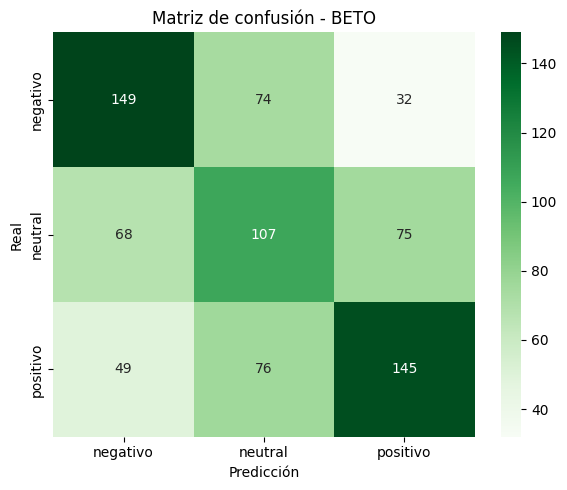

In [13]:
cm_beto = confusion_matrix(y_test_ids, y_pred_beto)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_beto, annot=True, fmt="d", cmap="Greens", xticklabels=ETIQUETAS, yticklabels=ETIQUETAS)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - BETO")
plt.tight_layout()
plt.show()

**Sección 6: Comparación de modelos**

| Métrica | Naive Bayes | BETO |
|---|---|---|
| Accuracy | 59.0% | 54.5% |
| F1 negativo | 0.65 | 0.61 |
| F1 neutral | 0.42 | 0.45 |
| F1 positivo | 0.66 | 0.57 |

Naive Bayes superó a BETO en este proyecto. BETO mostró mejora consistente
con más épocas, sugiriendo que con más recursos superaría al modelo clásico.
La clase "neutral" fue la más difícil para ambos modelos.

**Sección 7: Interfaz de uso**

In [14]:
def recomendacion_desde_sentimiento(sentimiento):
    if sentimiento == "positivo":
        return "Recomendada"
    elif sentimiento == "negativo":
        return "No recomendada"
    else:
        return "Depende del gusto (opiniones mixtas)"


def crear_funcion_analisis(prep, clf_nb, modelo_lda, diccionario, bigram_model, quitar_genericas, nombres_temas):
    def analizar_resena(texto_resena):
        if not texto_resena or not texto_resena.strip():
            return "Por favor pega una reseña", "", ""
        texto_proc = prep.pipeline_completo(texto_resena)
        sentimiento_pred = clf_nb.predecir(texto_proc)
        texto_lda = quitar_genericas(texto_proc)
        tokens_lda = bigram_model[texto_lda.split()]
        bow = diccionario.doc2bow(tokens_lda)
        distribucion_temas = modelo_lda.get_document_topics(bow)
        if len(distribucion_temas) == 0:
            tema_nombre = "No se pudo determinar"
        else:
            tema_id = max(distribucion_temas, key=lambda x: x[1])[0]
            tema_nombre = nombres_temas.get(tema_id, f"Tema {tema_id}")
        recomendacion = recomendacion_desde_sentimiento(sentimiento_pred)
        return sentimiento_pred.upper(), tema_nombre, recomendacion
    return analizar_resena


def crear_interfaz(prep, clf_nb, modelo_lda, diccionario, bigram_model, quitar_genericas, nombres_temas):
    import gradio as gr
    analizar_resena = crear_funcion_analisis(prep, clf_nb, modelo_lda, diccionario, bigram_model, quitar_genericas, nombres_temas)

    ejemplos = [
        ["Una obra maestra del cine, con actuaciones brillantes y un guion que atrapa. Totalmente recomendable."],
        ["Pésima película, aburrida y sin sentido. No la recomiendo para nada."],
        ["Tiene momentos interesantes pero en general se siente repetitiva."],
    ]

    with gr.Blocks(title="Análisis de Críticas de Cine") as demo:
        gr.Markdown("# Sistema de Análisis de Críticas de Cine en Español")
        gr.Markdown("Pega una crítica y el sistema analizará su sentimiento, tema y recomendación.")
        entrada = gr.Textbox(label="Pega aquí la crítica de cine", lines=6)
        boton = gr.Button("Analizar", variant="primary")
        with gr.Row():
            salida_sentimiento = gr.Textbox(label="Sentimiento detectado")
            salida_tema = gr.Textbox(label="Tema / género predominante")
            salida_recomendacion = gr.Textbox(label="¿Recomendada?")
        boton.click(fn=analizar_resena, inputs=entrada, outputs=[salida_sentimiento, salida_tema, salida_recomendacion])
        gr.Examples(examples=ejemplos, inputs=entrada)

    return demo


app = crear_interfaz(prep, clf_nb, modelo_lda, diccionario, bigram_model, quitar_genericas, nombres_temas)
app.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6fdc8a6579856c5d37.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6fdc8a6579856c5d37.gradio.live
